# CIC nid Preprocessing and model evaluation

Here as an initial step I'm importing all the necessary module required for preprocessinf and model evaluation

In [12]:
# Core ML imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# Your chosen models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# Step 1 Loading the data

In [14]:
# Example: load one of the days
df = pd.read_csv("/content/drive/MyDrive/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX[1].csv")

print(df.shape)
print(df.head())


(286467, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22         1266342                  41   
1                 22         1319353                  41   
2                 22             160                   1   
3                 22         1303488                  41   
4              35396              77                   1   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       44                         2664   
1                       44                         2664   
2                        1                            0   
3                       42                         2728   
4                        2                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                          6954                     456   
1                          6954                     456   
2                             0                       0   
3                          6634    

# Step 2 Handling missing / infinite values

In [15]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

#Step 3 Encode labels

In [16]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [17]:
# Strip spaces in all column names
df.columns = df.columns.str.strip()

# Now you should have 'Label' instead of ' Label'
print(df.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [18]:

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])


## Step 4 Train-Test Split

In [19]:
# Separate features (X) and target (y)
X = df.drop('Label', axis=1)   # all columns except Label
y = df['Label']                # target column

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (228876, 78)
Test shape: (57220, 78)


# Step 5: Scaling and PCA

In [20]:
# 1. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Apply PCA
pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("Reduced features (PCA):", X_train_pca.shape[1])


Original features: 78
Reduced features (PCA): 22


## Step 6 Handle Class Imbalance (SMOTE)

CICIDS2017 is imbalanced (some attack types are rare).

Options:

 1. Use SMOTE (oversampling)

 2. Class weights in models (class_weight='balanced')

In [21]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


## Step 7 Model Trainig

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced", C=0.5
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, max_depth=8, min_samples_split=10, min_samples_leaf=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, random_state=42, n_jobs=-1,
        max_depth=12, min_samples_split=10, min_samples_leaf=5,
        class_weight="balanced_subsample"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42, n_estimators=150,
        learning_rate=0.1, max_depth=3
    )
}
trained_models = {}

for name, model in models.items():
    print(f"Training {name} with PCA features...")
    model.fit(X_train_pca, y_train)
    trained_models[name] = model
    print(f"{name} ✅ trained successfully")

for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy (PCA): {acc:.4f}")



Training Logistic Regression with PCA features...
Logistic Regression ✅ trained successfully
Training Decision Tree with PCA features...
Decision Tree ✅ trained successfully
Training Random Forest with PCA features...
Random Forest ✅ trained successfully
Training Gradient Boosting with PCA features...
Gradient Boosting ✅ trained successfully
Logistic Regression Accuracy (PCA): 0.9968
Decision Tree Accuracy (PCA): 0.9993
Random Forest Accuracy (PCA): 0.9999
Gradient Boosting Accuracy (PCA): 0.9997


## Accuaracy comparision

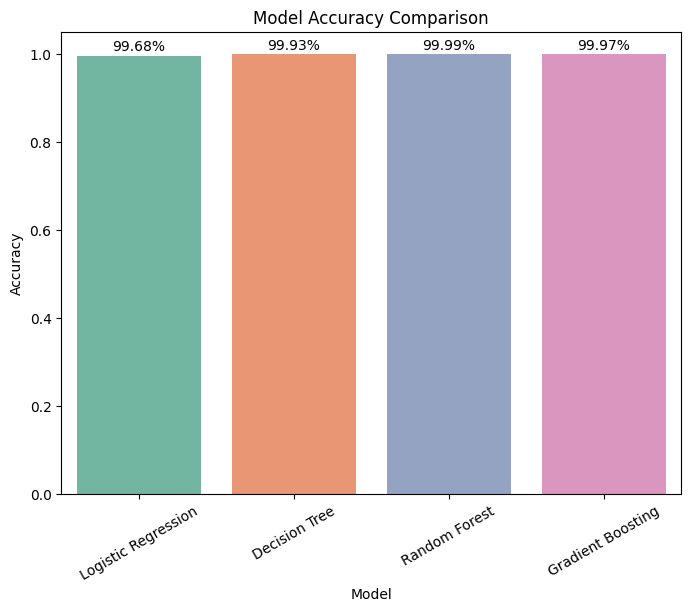

In [24]:

from sklearn.metrics import accuracy_score

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results)
plt.figure(figsize=(8,6))
barplot = sns.barplot(
    x='Model', y='Accuracy', hue='Model',
    data=results_df, dodge=False, palette="Set2", legend=False
)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)

# Add percentage labels on top of bars
for bar in plt.gca().patches:
    height = bar.get_height()
    plt.gca().text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height*100:.2f}%",
        ha='center'
    )
plt.show()


## Confusion matrix

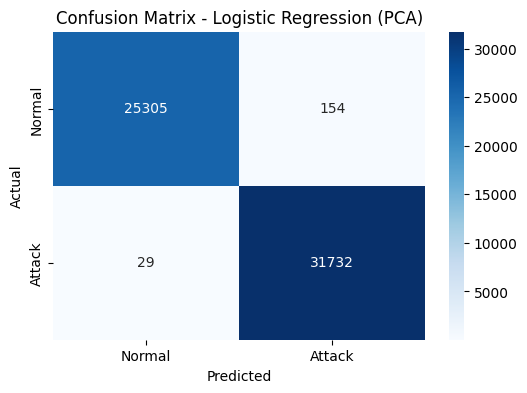

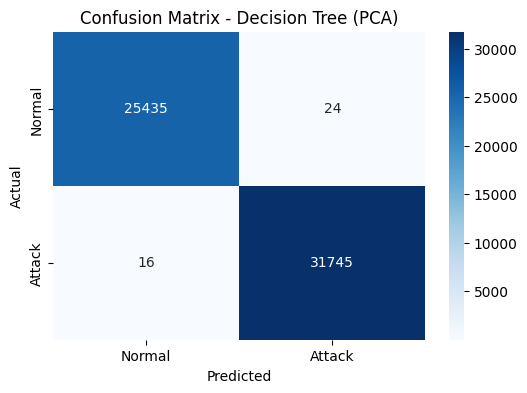

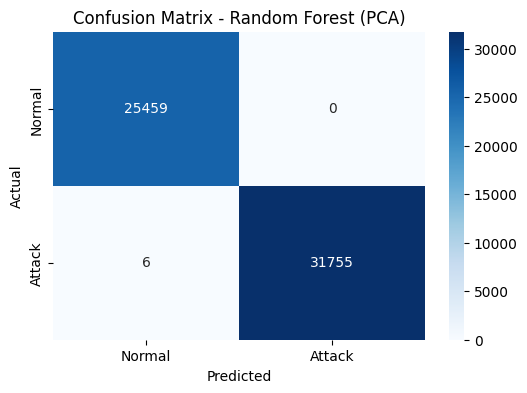

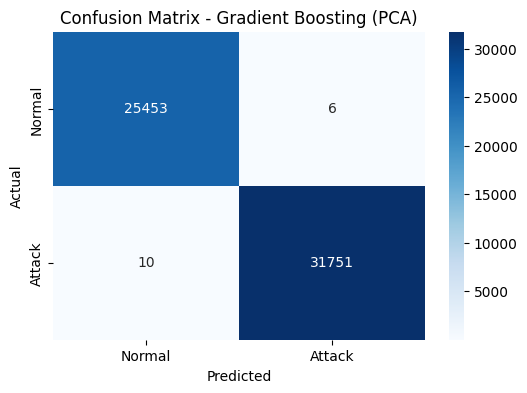

In [25]:
# Loop through all models and plot confusion matrix
for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title(f'Confusion Matrix - {name} (PCA)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()




## ROC Curve

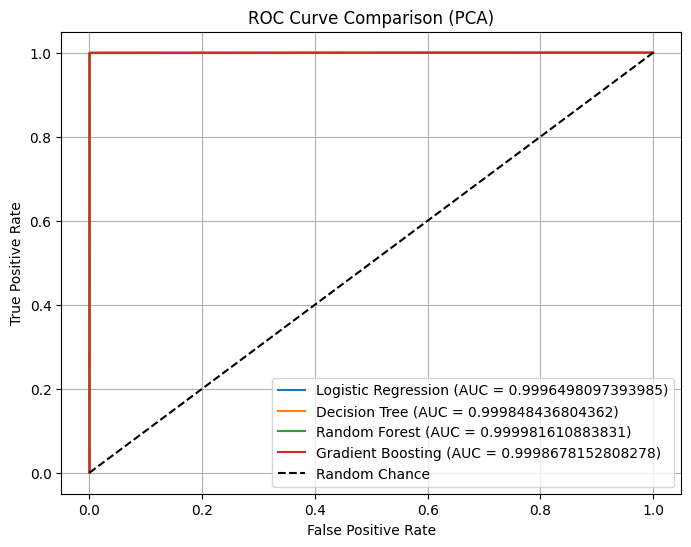

In [26]:
plt.figure(figsize=(8,6))
for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test_pca)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score})')  # no rounding

plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.title('ROC Curve Comparison (PCA)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Correlation HeatMap

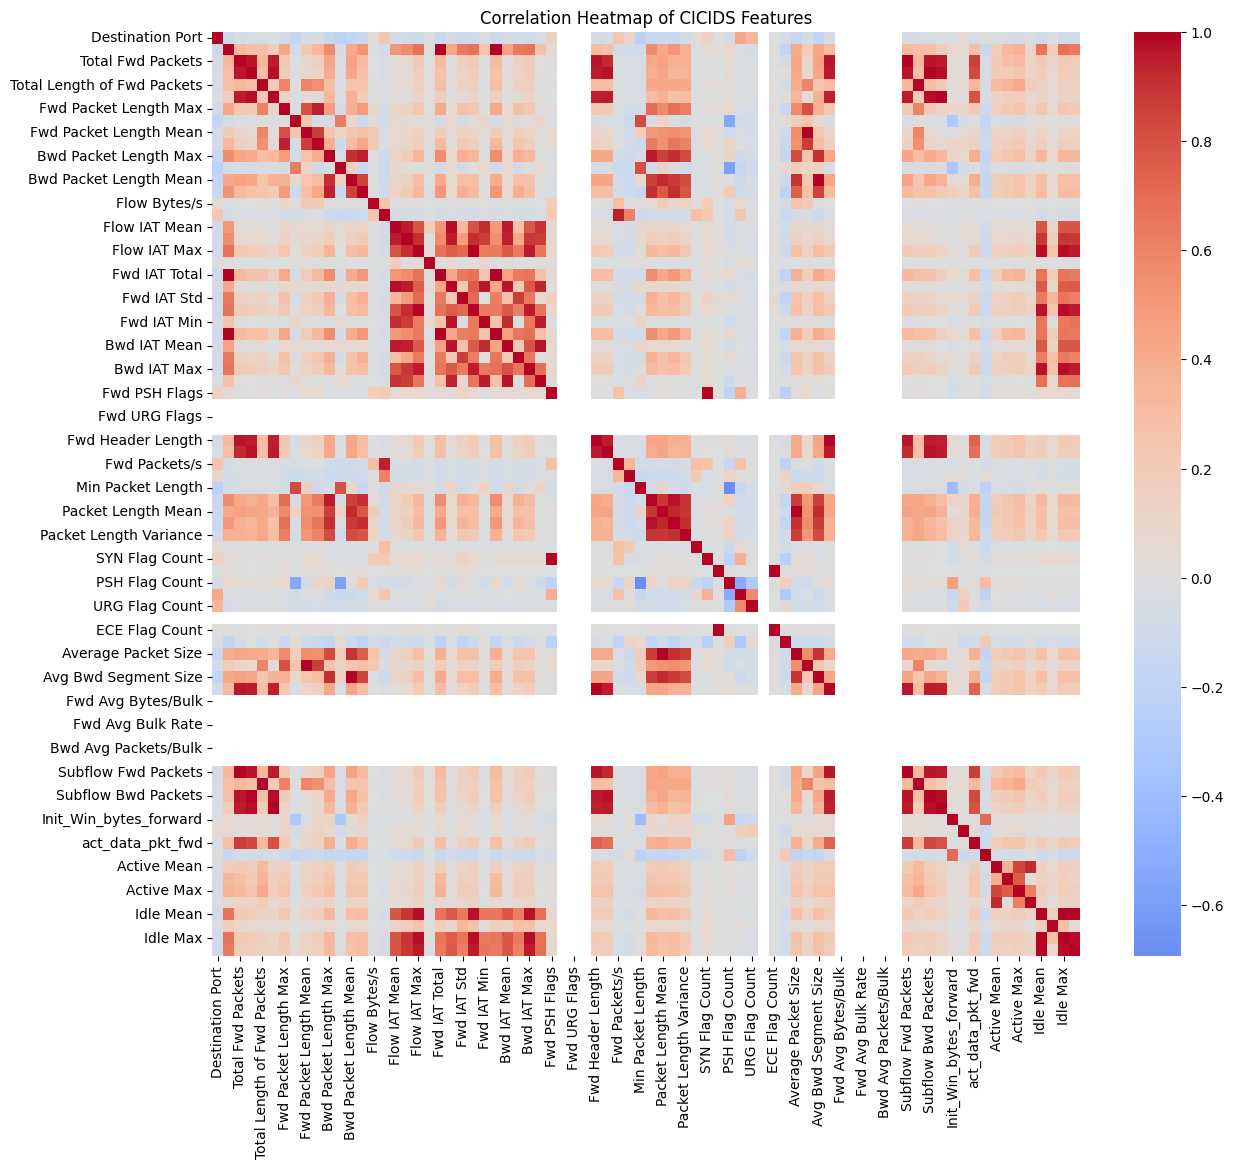

In [27]:
plt.figure(figsize=(14, 12))
corr_cicids = X_train.corr()
sns.heatmap(corr_cicids, cmap='coolwarm', center=0, annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Heatmap of CICIDS Features')
plt.show()
